In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [26]:
 

base_path = r"/Users/kdt_0900_lyn/ml/resoce/dataset"
file_name = r"pulsar_star.csv"
file_path = os.path.join(base_path, file_name) 

In [27]:
df = pd.read_csv(file_path)
df

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0
...,...,...,...,...,...,...,...,...,...
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12524,115.617188,46.784600,0.218177,0.226757,6.140468,NaN,5.732201,34.357283,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0


# 펄서와 우주잡음의 분류(classification) 문제 - KNN이 필요한 모델
- 펄서 별(Pulsar Star) 데이터셋은 지구에 도착한 전파 관측 신호를 바탕으로 치이익- 하는 배경 우주 잡음과 진짜 펄서 별이 보내는 맥박 형태의 전파 신호를 구별하는 이진 분류(Binary Classification) 데이터셋입니다. 자전하며 주기적인 빔을 쏘는 펄서 특유의 물리적 성질 때문에, 일반 잡음과 달리 평균 신호 세기(signal_power)는 낮고 신호의 변동 폭(signal_spread)은 크게 튀는 독특한 데이터 분포를 가집니다.

### 펄서 별(Pulsar Star) 데이터셋 컬럼 명세

| 컬럼명 | 데이터 타입 | 설명 |
| :--- | :--- | :--- |
| **Mean of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **평균값** (신호의 전체적인 세기) |
| **Standard deviation of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **표준편차** (신호 세기의 변동폭) |
| **Excess kurtosis of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **첨도** (신호 분포의 뾰족함 정도) |
| **Skewness of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **왜도** (신호 분포의 치우침 정도) |
| **Mean of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **평균값** |
| **Standard deviation of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **표준편차** |
| **Excess kurtosis of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **첨도** |
| **Skewness of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **왜도** |
| **target_class** | Integer | **클래스 라벨 (0: 우주 잡음 / 1: 진짜 펄서 별)** |

In [28]:
star_df = df[[" Mean of the integrated profile", " Standard deviation of the integrated profile", "target_class"]]
star_df

,Mean of the integrated profile,Standard deviation of the integrated profile,target_class
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [29]:
star_df.columns = ["signal_mean_power" , "signal_spread", "target"]

In [30]:
star_df["target"].value_counts()

target
0.0    11375
1.0     1153
Name: count, dtype: int64

## 언더 샘플링 (데이터 불균형 해결)

In [31]:
df_0 = star_df[star_df["target"]==0]
df_1 = star_df[star_df["target"]==1]
print(len(df_0), len(df_1))

# 무작위로 뽑기 
df_0_sampled = df_0.sample(n=len(df_1), random_state=2026)
print(len(df_0_sampled))

11375 1153
1153


In [32]:
print(type(df_1)), type(df_0_sampled)

<class 'pandas.DataFrame'>


(None, pandas.DataFrame)

In [33]:
pd.concat([df_1, df_0_sampled]).sample(frac=1, random_state= 2026).reset_index(drop=True)

star_df.head()

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0


## 사이킷런 KNN 분류 사이클 실습 

## 1단계 , 데이터 전처리 
- 데이터 EDA
- 데이터의 정보 (info) - 결측치 여부 확인, 데이터의 타입 확인(수치형인지 분류형인지)
- 데이터 기술 통계량 (describe) - 4분위수 , 이상치
- 데이터 EDA
- 결측치 , 이상치 처리
- 표준화 또는 정규화

In [34]:
star_df.info() 
# signal_mean_power : 수치형 
# signal_spread ; 수치형
# target : 분류 

<class 'pandas.DataFrame'>
RangeIndex: 12528 entries, 0 to 12527
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   signal_mean_power  12528 non-null  float64
 1   signal_spread      12528 non-null  float64
 2   target             12528 non-null  float64
dtypes: float64(3)
memory usage: 293.8 KB


In [35]:
# 타입 바꾸기 : astype(타입)


In [36]:
# 수치형 -> 평균, 중앙 
# 분류형 -> 최빈값 

In [37]:
star_df.describe()

,signal_mean_power,signal_spread,target
count,12528.000000,12528.000000,12528.000000
mean,111.041841,46.521437,0.092034
std,25.672828,6.801077,0.289085
min,5.812500,24.772042,0.000000
25%,100.871094,42.362222,0.000000
50%,115.183594,46.931022,0.000000
75%,127.109375,50.979103,0.000000
max,189.734375,91.808628,1.000000


In [38]:
# 1. 진짜 별
# 실호의 편귱 세기가 작은 값이 진짜 별
star_df.iloc[star_df["signal_mean_power"].idxmin()]
# 0: 우주 잡음 
star_df.iloc[star_df["signal_mean_power"].idxmax()]

signal_mean_power    189.734375
signal_spread         59.578268
target                 0.000000
Name: 9254, dtype: float64

In [39]:
star_df.iloc[star_df["signal_spread"].idxmin()]

star_df.iloc[star_df["signal_spread"].idxmax()]


signal_mean_power    101.242188
signal_spread         91.808628
target                 0.000000
Name: 10846, dtype: float64

In [40]:
star_df["target"] = star_df["target"].astype(int)
star_df

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0
1,76.968750,36.175557,0
2,130.585938,53.229534,0
3,156.398438,48.865942,0
4,84.804688,36.117659,0
...,...,...,...
12523,124.312500,53.179053,0
12524,115.617188,46.784600,0
12525,116.031250,43.213846,0
12526,135.664062,49.933749,0


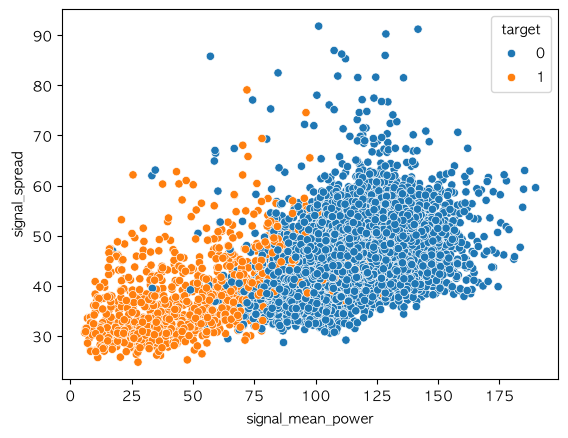

In [41]:
sns.scatterplot(star_df, x="signal_mean_power", y= "signal_spread", hue="target")
plt.xlim()
plt.ylim()
plt.show()

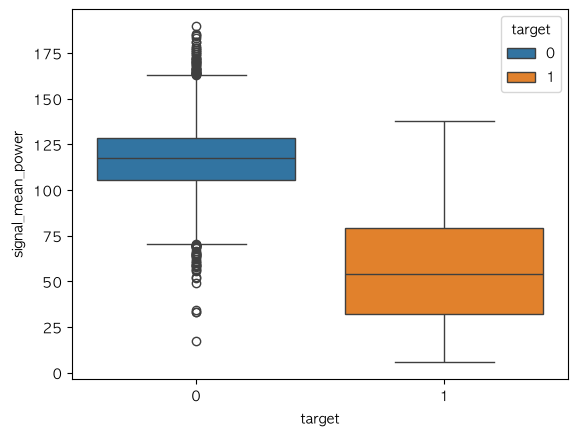

In [42]:
sns.boxplot(star_df, x="target", y= "signal_mean_power", hue="target")
plt.show()

## 독립 변수와 종속 변수 


In [48]:
X = star_df["target"]
X.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [49]:
y = star_df["target"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=2026)

In [51]:
scaler = StandardScaler()

# 1. 스케일 하고 나누기
# 2. 나누고 스케일하기
scaler.fit_transform(X_train)
scaler.transform(X_test)

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

## 2단계 모델 준비 


In [ ]:
kn = KNeighborsClassifier()

In [ ]:
# KNeighborsClassifier : 변경 간능 (: 하이퍼 파라미터)

### 하이퍼 파리미터 (Hyper Parameter)
- 사람 (개발자 또는 분석가)가 필요에 따라 직접 설정하는 파라미터의 값을 의미한다
### 파리미터(Parameter)
- 모델이 학습(fit)을 통해 스스로 찾아내는 값을 의미ㄹ한다 

In [55]:
kn = KNeighborsClassifier(n_neighbors=5)

## 3단계 모델 학습 

In [56]:
kn.fit(X_train_scaled, y_train)

NameError: name 'X_train_scaled' is not defined

In [54]:
y_pred = kn.predict(X_train_scaled)
y_pred[:10]

NameError: name 'X_train_scaled' is not defined

In [ ]:
print(f"모델 정확도 점수 : {kn.score(y_pred, y_test)}")

In [59]:
# 1~20 까지 n_neighbors개수 중 최적의 개수를 찾기 
train_scores = []
test_score = []

for i in range(1, 21):
    kn = KNeighborsClassifier(n_neighbors=k)
    train_scores.append(kn.score(X_train_scaled , y_train))
    test_scores.append(kn.score(X_train_scaled , y_test))

NameError: name 'k' is not defined

In [ ]:
print(train_scores)
print(test_scores)

In [ ]:
train_k = train_scores.index(max(train_scores)) + 1
test_k = test_scores.index(max(test_scores)) + 1

print(f"훈련의 데이터셋의 최적의 k 개수 : {train_k}")
print(f"훈련의 데이터셋 : {test_k }")

In [ ]:
new_data = pd.DataFrame([[]50, 60]), column=["", ""] 
new_data_scaled = scaler.transform(new_data)
new_data_scaled

In [ ]:
aistances, indexs = kn.kneighbors(new_data_scaled)
aistances, indexs

In [ ]:
# signal_mean_power, signal_spread
plt.figure(figsize=(8,6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c="lightgray", label="Train Data", alpha=0.5)

neighbor_data = X_train_scaled[indexs[0]]
plt.scatter(neighbor_data[:, 0], neighbor_data[:, 1], marker="^", color="green", label="Neighbors")
plt.scatter(new_data_scaled[0, 0], new_data_scaled[0, 1], marker="*", color="orange", label="New Data")
plt.legend()
plt.show()

In [ ]:
kn.predict(new_data_scaled)

## 4단계, 모델 평가 

In [61]:
cm = confusion_matrix(y_testm y_pred)
cm

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Noise(0)", "Pulser(1)"])
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Signature:
confusion_matrix(
    y_true,
    y_pred,
    *,
    labels=None,
    sample_weight=None,
    normalize=None,
)
Docstring:
Compute confusion matrix to evaluate the accuracy of a classification.

By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
is equal to the number of observations known to be in group :math:`i` and
predicted to be in group :math:`j`.

Thus in binary classification, the count of true negatives is
:math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
:math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

Read more in the :ref:`User Guide <confusion_matrix>`.

Parameters
----------
y_true : array-like of shape (n_samples,)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,)
    Estimated targets as returned by a classifier.

labels : array-like of shape (n_classes,), default=None
    List of labels to index the matrix. This may be used to reorder
    or select a subset of labels.
    I

In [ ]:
classification_report(y_test, y_pred)